In [1]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from typing import Tuple

We plot the evaluation and train error for different degrees in the polynomial regression.
First we generate the data synthetically using this function:
$$
f(x) = 0.421x^{4} + 6.642x^{2} + 1.676x + \epsilon
$$

The noise is drawn from a normal distribution.
$$
\epsilon \sim \mathcal{N}(0, 2)
$$

In [2]:
def data_generator(num_data: int = 50) -> np.ndarray:
    """
    Generate synthetic data for polynomial function 0.421*x^4 + 6.642*x^2 + 1.676*x + epsilon

    Args:
        num_data (int): Number of the data points we want to generate.

    Returns:
        Tuple (X, y): A Tuple of features and y.
    """
    np.random.seed(50)
    X = np.random.uniform(-2, 2, num_data)
    # Draw the noise
    epsilon = np.random.normal(0, 2, num_data)
    # Calculate the function
    y = 1.8241 * X ** 3 + 6.642 * X**2 + 0.676 * X + epsilon
    # Stack X and y 
    data = np.stack((X, y), axis = 1)

    return X.reshape(-1, 1), y.reshape(-1, 1)



In [3]:
X, y = data_generator()
# Divide the Data into Train, Evaluation, and Test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 50)
X_eval, X_test, y_eval, y_test = train_test_split(X_test, y_test, test_size = 0.5, random_state = 10)

degrees = [i for i in range(0, 21, 2)]
train_error = []
eval_error = []

for m in degrees:
    # Pipeline
    poly_reg_pipeline = Pipeline([
    ("poly", PolynomialFeatures(m)),
    ("linreg", LinearRegression()) 
    ])
    # Fit the model and make predictions for train and evaluation data
    poly_reg_pipeline.fit(X_train, y_train)
    train_predict = poly_reg_pipeline.predict(X_train)
    eval_predict = poly_reg_pipeline.predict(X_eval)
    # Calculate the RMSE for train and evaluation data
    train_error.append(root_mean_squared_error(y_true = y_train, y_pred = train_predict))
    eval_error.append(root_mean_squared_error(y_true = y_eval, y_pred = eval_predict))



Now we plot the Evaluation and train error results to see the underfitting and Overfitting of the data with increasing degree of the polynomial model

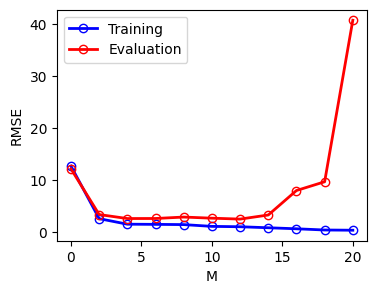

In [4]:
plt.figure(figsize = (4, 3))
# Training data
plt.plot(degrees, train_error, marker = "o", markerfacecolor = "none",
          linestyle = "-",color = "blue", linewidth = 2, label = "Training")

# Evaluation data
plt.plot(degrees, eval_error, marker = "o", markerfacecolor = "none",
          linestyle = "-", color = "red", linewidth = 2, label = "Evaluation")

plt.xlabel("M")
plt.ylabel("RMSE")
plt.legend()
plt.show()